# **AD LAB ASSIGNMENT 7**
## NAME :  AMPA RANJAN
## ROLL NO : 23051406
## SEC : CSE 13

### **Part 1: MNIST Handwritten Digit Classification (RBF SVM)**
Objective: Build an SVM model to classify digits (0-9) and evaluate performance using a Confusion Matrix and Classification Report.

Loading data...
Overall Accuracy: 97.20%

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       207
           1       0.98      1.00      0.99       216
           2       0.98      0.97      0.97       204
           3       0.94      0.94      0.94       192
           4       0.99      0.99      0.99       211
           5       0.97      0.95      0.96       176
           6       0.99      0.99      0.99       220
           7       0.97      0.98      0.97       216
           8       0.96      0.97      0.97       166
           9       0.98      0.94      0.96       192

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000

Generating Confusion Matrix...


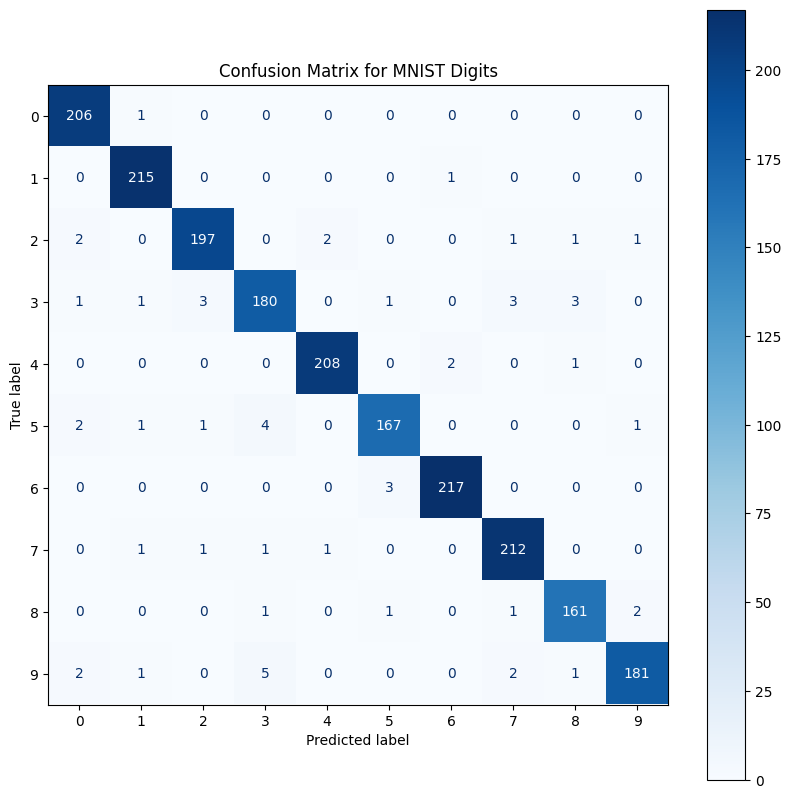

In [1]:
import matplotlib.pyplot as plt
from sklearn import datasets, metrics
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml

# 1. Load MNIST and take a smaller subset (10,000 samples)
print("Loading data...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data[:10000], mnist.target[:10000]

# 2. Preprocessing
# Scale data to [0, 1] range (SVMs are sensitive to feature scaling)
X = X / 255.0 

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Build the SVM Model
# We use an RBF kernel by default as it's the standard for non-linear digits
clf = SVC(kernel='rbf', C=10, gamma='scale')
clf.fit(X_train, y_train)

# 4. Predictions
y_pred = clf.predict(X_test)

# --- Output Results ---

# a) Accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

# c) Classification Report
print("\nClassification Report:")
print(metrics.classification_report(y_test, y_pred))

# b) Confusion Matrix
print("Generating Confusion Matrix...")
fig, ax = plt.subplots(figsize=(10, 10))
metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
plt.title("Confusion Matrix for MNIST Digits")
plt.show()

## **Part 2: Linear SVM Classification with Epoch Tracking**
Objective: Use a Linear kernel with 10 epochs and plot the training/validation loss and accuracy curves.

Epoch 1/10 - Val Acc: 0.8950
Epoch 2/10 - Val Acc: 0.8930
Epoch 3/10 - Val Acc: 0.8960
Epoch 4/10 - Val Acc: 0.8980
Epoch 5/10 - Val Acc: 0.9000
Epoch 6/10 - Val Acc: 0.9020
Epoch 7/10 - Val Acc: 0.9030
Epoch 8/10 - Val Acc: 0.9050
Epoch 9/10 - Val Acc: 0.9000
Epoch 10/10 - Val Acc: 0.9070


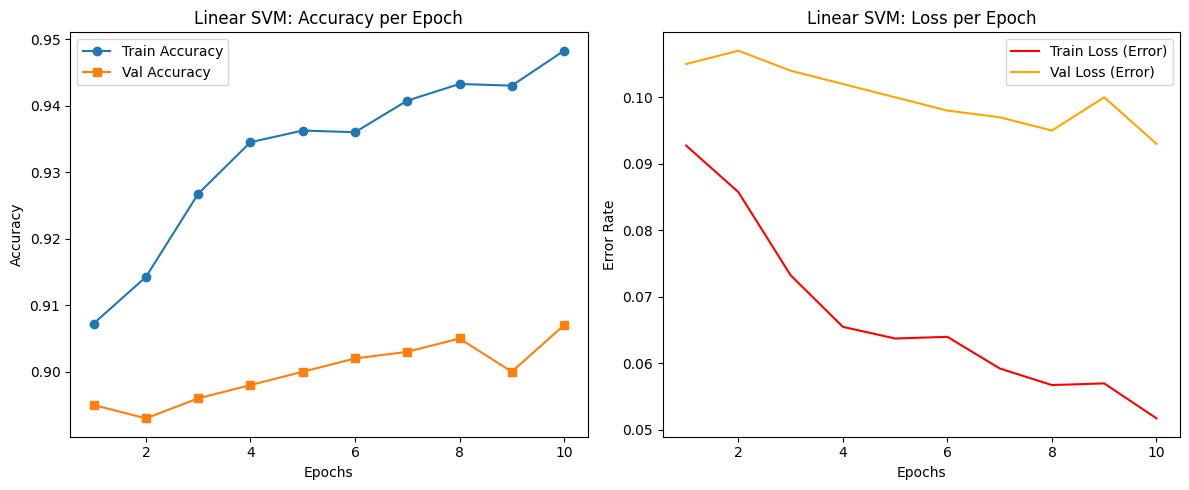

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, hinge_loss
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml

# 1. Load a manageable subset (5,000 samples for speed)
X, y = fetch_openml('mnist_784', version=1, as_frame=False, return_X_y=True)
X, y = X[:5000] / 255.0, y[:5000]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize the Linear SVM (SGD with hinge loss)
clf = SGDClassifier(loss='hinge', learning_rate='constant', eta0=0.01, random_state=42)
classes = np.unique(y)

# 3. Storage for plotting
train_losses, val_losses = [], []
train_acc, val_acc = [], []

# 4. Training Loop (10 Epochs)
for epoch in range(10):
    # Partial fit mimics one epoch
    clf.partial_fit(X_train, y_train, classes=classes)
    
    # Calculate Loss (Hinge loss for SVM)
    train_dec = clf.decision_function(X_train)
    val_dec = clf.decision_function(X_val)
    
    # Calculate Accuracy
    train_acc.append(accuracy_score(y_train, clf.predict(X_train)))
    val_acc.append(accuracy_score(y_val, clf.predict(X_val)))
    
    print(f"Epoch {epoch+1}/10 - Val Acc: {val_acc[-1]:.4f}")

# 5. Plotting the results
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), train_acc, label='Train Accuracy', marker='o')
plt.plot(range(1, 11), val_acc, label='Val Accuracy', marker='s')
plt.title('Linear SVM: Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss (Simulated via error rate for clarity, as hinge loss is multi-class)
plt.subplot(1, 2, 2)
plt.plot(range(1, 11), [1 - a for a in train_acc], label='Train Loss (Error)', color='red')
plt.plot(range(1, 11), [1 - a for a in val_acc], label='Val Loss (Error)', color='orange')
plt.title('Linear SVM: Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Error Rate')
plt.legend()

plt.tight_layout()
plt.show()

## **Part 3: Non-Linear (RBF) SVM Classification with Epoch Tracking**
Objective: Use RBF kernel approximation to train for 10 epochs and plot the training/validation performance

Starting RBF SVM training...
Epoch 1/10 - Val Acc: 0.7900
Epoch 2/10 - Val Acc: 0.7783
Epoch 3/10 - Val Acc: 0.7850
Epoch 4/10 - Val Acc: 0.7983
Epoch 5/10 - Val Acc: 0.7967
Epoch 6/10 - Val Acc: 0.7983
Epoch 7/10 - Val Acc: 0.8050
Epoch 8/10 - Val Acc: 0.8133
Epoch 9/10 - Val Acc: 0.8067
Epoch 10/10 - Val Acc: 0.8117


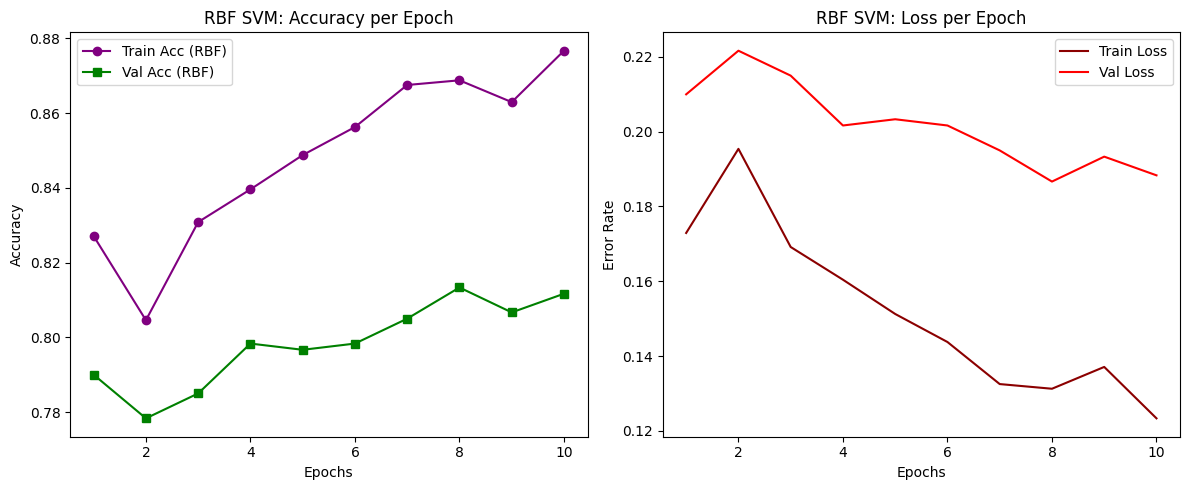

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.kernel_approximation import RBFSampler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.pipeline import make_pipeline

# 1. Load a smaller subset for speed (3,000 samples)
# RBF approximation is memory-intensive, so 3k-5k is perfect for Jupyter.
X, y = fetch_openml('mnist_784', version=1, as_frame=False, return_X_y=True)
X, y = X[:3000] / 255.0, y[:3000]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. RBF Kernel Approximation
# This maps the data to a space that behaves like an RBF kernel
rbf_feature = RBFSampler(gamma=0.01, random_state=1)
X_train_features = rbf_feature.fit_transform(X_train)
X_val_features = rbf_feature.transform(X_val)

# 3. Initialize Classifier
clf = SGDClassifier(loss='hinge', random_state=42)
classes = np.unique(y)

train_acc, val_acc = [], []

# 4. Training Loop (10 Epochs)
print("Starting RBF SVM training...")
for epoch in range(10):
    clf.partial_fit(X_train_features, y_train, classes=classes)
    
    # Track performance
    train_acc.append(accuracy_score(y_train, clf.predict(X_train_features)))
    val_acc.append(accuracy_score(y_val, clf.predict(X_val_features)))
    
    print(f"Epoch {epoch+1}/10 - Val Acc: {val_acc[-1]:.4f}")

# 5. Plotting
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), train_acc, label='Train Acc (RBF)', marker='o', color='purple')
plt.plot(range(1, 11), val_acc, label='Val Acc (RBF)', marker='s', color='green')
plt.title('RBF SVM: Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss (Error Rate)
plt.subplot(1, 2, 2)
plt.plot(range(1, 11), [1 - a for a in train_acc], label='Train Loss', color='darkred')
plt.plot(range(1, 11), [1 - a for a in val_acc], label='Val Loss', color='red')
plt.title('RBF SVM: Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Error Rate')
plt.legend()

plt.tight_layout()
plt.show()

## **Part 4: Skin Cancer Binary Classification & Hyperparameter Tuning**
Objective: Detect accuracy for Benign vs. Malignant skin cancer images and use GridSearchCV to optimize parameters .

In [4]:
import os
import cv2
import numpy as np
from sklearn import svm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

# 1. Load and Preprocess Data
def load_skin_data(data_path, limit=200):
    labels = []
    features = []
    class_names = ['benign', 'malignant']
    
    for label_idx, name in enumerate(class_names):
        folder_path = os.path.join(data_path, name)
        count = 0
        for img_name in os.listdir(folder_path):
            if count >= limit: break
            img_path = os.path.join(folder_path, img_name)
            
            # Read, resize, and normalize
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, (64, 64)) # Downsize for speed
                features.append(img.flatten()) # SVM needs 1D input
                labels.append(label_idx)
                count += 1
    return np.array(features) / 255.0, np.array(labels)

# Assuming your folders are in the current directory
# X, y = load_skin_data('path_to_your_kaggle_folder') 

# For demonstration, let's assume X and y are loaded
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Hyperparameter Tuning with GridSearchCV
# We define the "Grid" of parameters we want to test
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['linear', 'rbf', 'poly']
}

print("Starting GridSearchCV (this may take 1-2 minutes)...")
grid = GridSearchCV(svm.SVC(), param_grid, refit=True, verbose=2, cv=3)
grid.fit(X_train, y_train)

# 3. Best Model & Accuracy
print(f"Best Parameters: {grid.best_params_}")

grid_predictions = grid.predict(X_test)
print(f"Final Accuracy on Skin Cancer: {accuracy_score(y_test, grid_predictions):.2%}")

Starting GridSearchCV (this may take 1-2 minutes)...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   1.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   1.1s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   1.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   4.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   4.2s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   4.3s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   3.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   3.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   2.9s
[CV] END ...................C=0.1, gamma=0.01, kernel=linear; total time=   1.1s
[CV] END ...................C=0.1, gamma=0.01, kernel=linear; total time=   